In [19]:
# first we convert .xml to yolo format 
import xml.etree.ElementTree as ET
from pathlib import Path

# Paths
IMG_DIR = Path("NEU_data/NEU-DET/train/images")
XML_DIR = Path("NEU_data/NEU-DET/train/annotations")

val_dir = Path("NEU_data/NEU-DET/validation/images")
xml_val = Path("NEU_data/NEU-DET/validation/annotations")

OUT_DIR = Path("NEU_data/NEU-DET/train/labels")
OUT_DIR.mkdir(parents=True, exist_ok=True)

val_out_dir = Path("NEU_data/NEU-DET/validation/labels")
val_out_dir.mkdir(parents=True, exist_ok=True)

# NEU-DET class names
CLASS_NAMES = ["crazing","inclusion","patches",
               "pitted_surface","rolled-in_scale","scratches"]

def xml_conversion(XML_DIR, OUT_DIR):
    for xml_file in XML_DIR.rglob("*.xml"):
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Image size
        img_w = int(root.find("size/width").text)
        img_h = int(root.find("size/height").text)

        yolo_lines = []

        # Loop over all objects (some images have multiple defects)
        for obj in root.findall("object"):
            cls_name = obj.find("name").text
            cls_id = CLASS_NAMES.index(cls_name)

            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            # Convert VOC → YOLO
            cx = (xmin + xmax) / 2 / img_w
            cy = (ymin + ymax) / 2 / img_h
            w  = (xmax - xmin) / img_w
            h  = (ymax - ymin) / img_h

            yolo_lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        # Save .txt
        out_file = OUT_DIR / (xml_file.stem + ".txt")
        out_file.write_text("\n".join(yolo_lines))

    print(f"✅ Conversion complete for: {XML_DIR}")

xml_conversion(XML_DIR, OUT_DIR)
xml_conversion(xml_val, val_out_dir)


✅ Conversion complete for: NEU_data\NEU-DET\train\annotations
✅ Conversion complete for: NEU_data\NEU-DET\validation\annotations


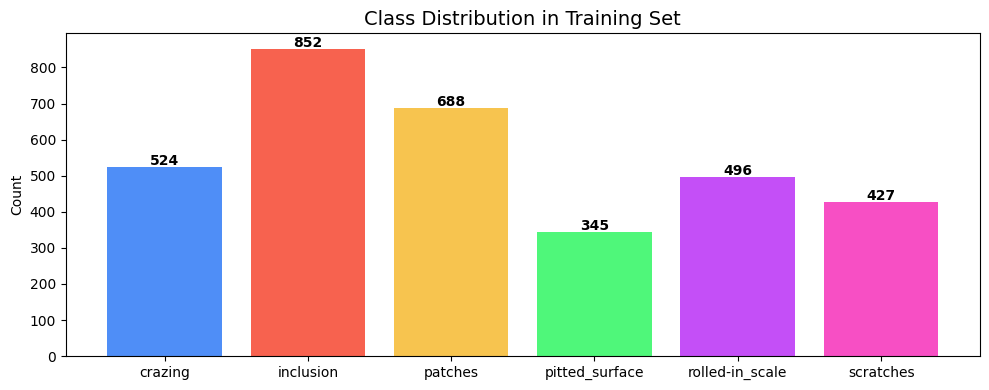

✅ Class distribution saved


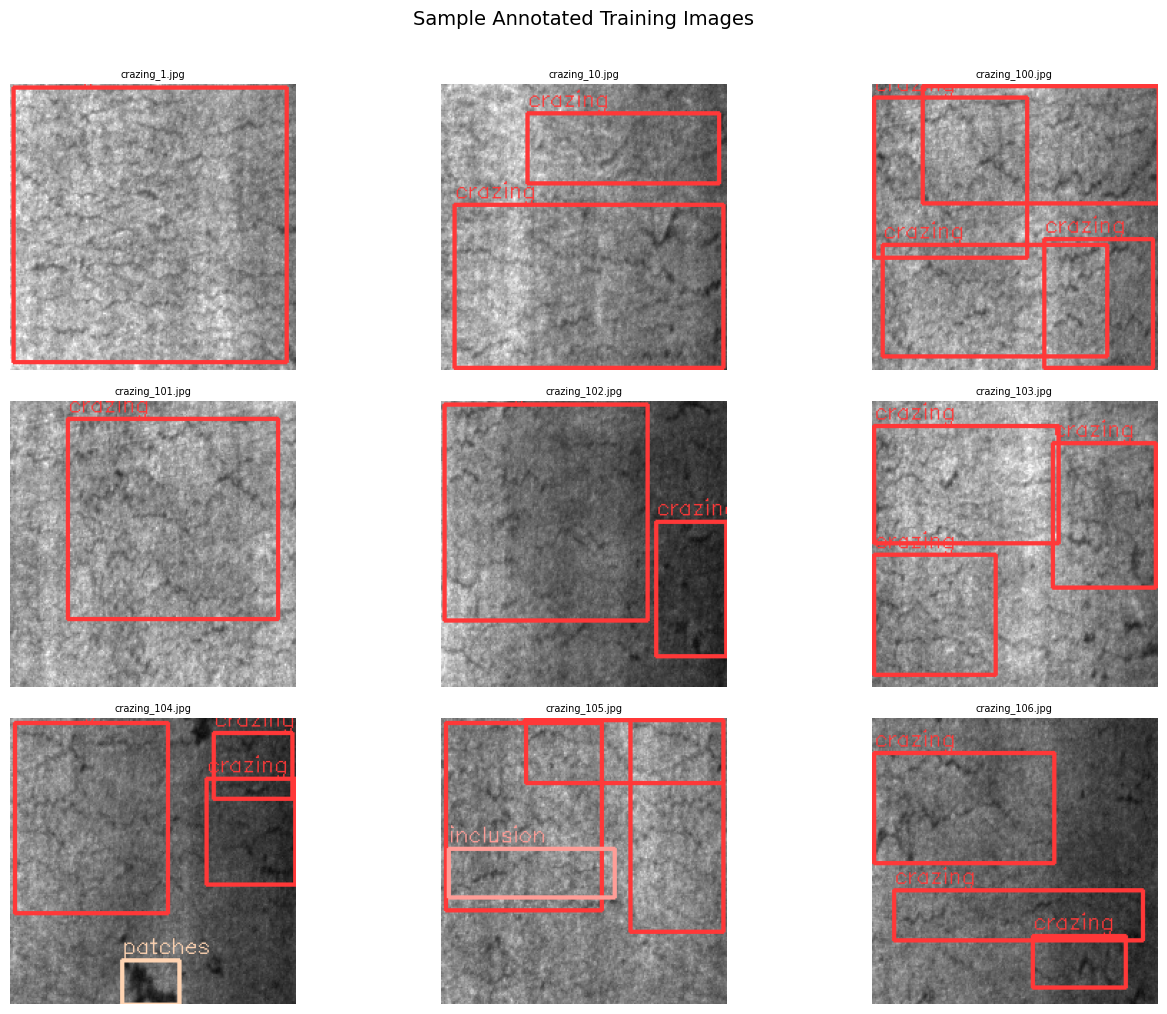

✅ Sample annotations saved


In [21]:
# validate_data.py
import os, cv2, matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter

# ── Config ───────────────────────────────────────────────
IMG_DIR   = "NEU_data/NEU-DET/train/images"
LBL_DIR   = "NEU_data/NEU-DET/train/labels"
CLASS_NAMES = ["crazing","inclusion","patches",
               "pitted_surface","rolled-in_scale","scratches"]
COLORS = [(255,56,56),(255,157,151),(255,212,178),
          (171,255,178),(79,194,255),(130,149,255)]

# ── 1. Class distribution ─────────────────────────────────
counts = Counter()
for f in Path(LBL_DIR).glob("*.txt"):
    for line in f.read_text().strip().splitlines():
        cls = int(line.split()[0])
        counts[cls] += 1

labels = [CLASS_NAMES[i] for i in sorted(counts)]
values = [counts[i] for i in sorted(counts)]

plt.figure(figsize=(10,4))
bars = plt.bar(labels, values, color=["#4f8ef7","#f7624f","#f7c44f",
                                       "#4ff77a","#c44ff7","#f74fc4"])
for bar, val in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(val), ha='center', fontweight='bold')
plt.title("Class Distribution in Training Set", fontsize=14)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("✅ Class distribution saved")

# ── 2. Visualize 9 random annotated samples ───────────────
img_paths = list(Path(IMG_DIR).rglob("*.jpg"))[:9]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, img_path in zip(axes.flat, img_paths):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = Path(LBL_DIR) / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            c, cx, cy, bw, bh = map(float, line.split())
            c = int(c)
            x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), COLORS[c], 2)
            cv2.putText(img, CLASS_NAMES[c], (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORS[c], 1)
    ax.imshow(img); ax.axis("off"); ax.set_title(img_path.name, fontsize=7)
plt.suptitle("Sample Annotated Training Images", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("sample_annotations.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sample annotations saved")